In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import seaborn as sns
from pygments.styles.dracula import background
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
from sklearn.metrics import accuracy_score, precision_score

ps=PorterStemmer()
from wordcloud import WordCloud
from collections import Counter

pycharm_bg = '#1E1F22'
plt.rcParams['figure.facecolor'] = pycharm_bg
plt.rcParams['axes.facecolor'] = pycharm_bg

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split as tts

from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

In [5]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\arham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [6]:
df=pd.read_csv("data/Updated_Dataset.csv")
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,text,target
0,CONGRATULATIONS! FREE 2GB data is yours! Claim...,1
1,Hi! Thank you for being with Vi-India's FASTES...,1
2,"As part of Cyber Swachhta Pakhwada, CERT-In Go...",1
3,I will try to manage took tablets,0
4,Study from Home with Vi!! Watch Kite Victers C...,1


In [7]:
print(df.shape)
print(df['target'].value_counts())


(109435, 2)
target
0    56973
1    52462
Name: count, dtype: int64


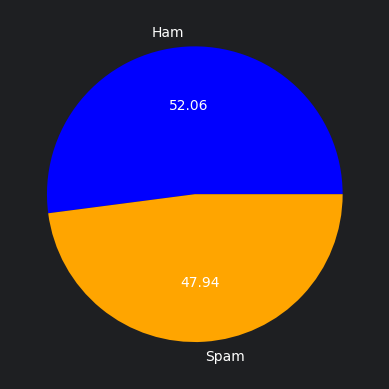

In [8]:
plt.pie(df['target'].value_counts(),labels=['Ham','Spam'], colors=['blue','orange'], autopct='%0.2f')
plt.show()

In [9]:
df['num_char']=df['text'].apply(lambda x:len(str(x).replace(" ","")))
df.head()

,text,target,num_char
0,CONGRATULATIONS! FREE 2GB data is yours! Claim...,1,90
1,Hi! Thank you for being with Vi-India's FASTES...,1,131
2,"As part of Cyber Swachhta Pakhwada, CERT-In Go...",1,123
3,I will try to manage took tablets,0,27
4,Study from Home with Vi!! Watch Kite Victers C...,1,115


In [10]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(str(x))))
df.head()

,text,target,num_char,num_words
0,CONGRATULATIONS! FREE 2GB data is yours! Claim...,1,90,17
1,Hi! Thank you for being with Vi-India's FASTES...,1,131,30
2,"As part of Cyber Swachhta Pakhwada, CERT-In Go...",1,123,27
3,I will try to manage took tablets,0,27,7
4,Study from Home with Vi!! Watch Kite Victers C...,1,115,28


In [11]:
df['num_sent']=df['text'].apply(lambda x:len(nltk.sent_tokenize(str(x))))
df.head()

,text,target,num_char,num_words,num_sent
0,CONGRATULATIONS! FREE 2GB data is yours! Claim...,1,90,17,4
1,Hi! Thank you for being with Vi-India's FASTES...,1,131,30,4
2,"As part of Cyber Swachhta Pakhwada, CERT-In Go...",1,123,27,2
3,I will try to manage took tablets,0,27,7,1
4,Study from Home with Vi!! Watch Kite Victers C...,1,115,28,4


In [12]:
df[df['target']==0][['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,56973.00000,56973.000000,56973.000000
mean,31.88900,7.082478,1.191406
std,28.04598,8.317853,0.716327
min,1.00000,1.000000,1.000000
25%,23.00000,4.000000,1.000000
50%,27.00000,5.000000,1.000000
75%,32.00000,7.000000,1.000000
max,1588.00000,476.000000,38.000000


In [13]:
df[df['target']==1][['num_char','num_words','num_sent']].describe()


,num_char,num_words,num_sent
count,52462.000000,52462.000000,52462.000000
mean,48.145953,9.860299,1.930464
std,21.088468,5.441015,0.747340
min,8.000000,1.000000,1.000000
25%,39.000000,7.000000,2.000000
50%,44.000000,9.000000,2.000000
75%,49.000000,11.000000,2.000000
max,537.000000,193.000000,52.000000


<Axes: xlabel='num_char', ylabel='Count'>

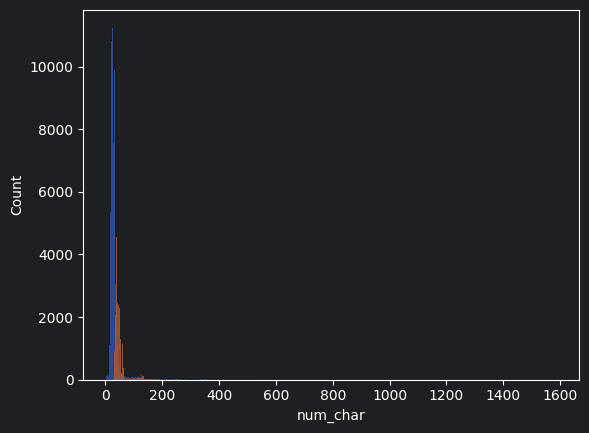

In [14]:
sns.histplot(df[df['target']==0]['num_char'])
sns.histplot(df[df['target']==1]['num_char'])

<Axes: xlabel='num_words', ylabel='Count'>

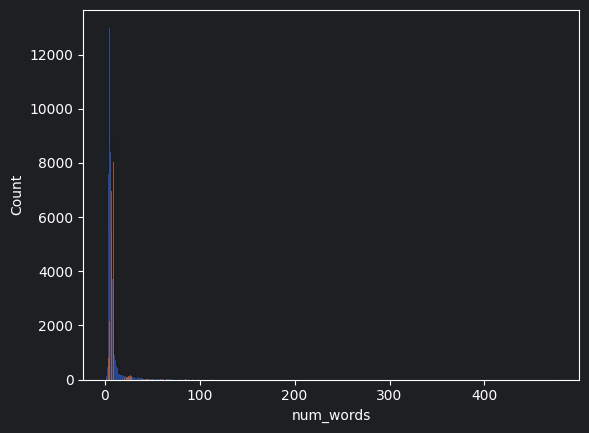

In [15]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'])

<Axes: xlabel='num_sent', ylabel='Count'>

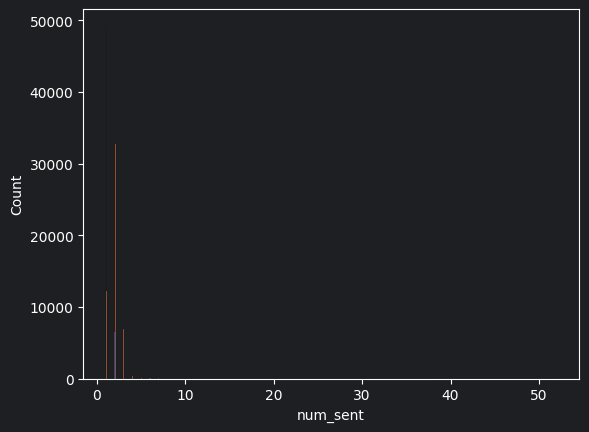

In [16]:
sns.histplot(df[df['target']==0]['num_sent'])
sns.histplot(df[df['target']==1]['num_sent'])

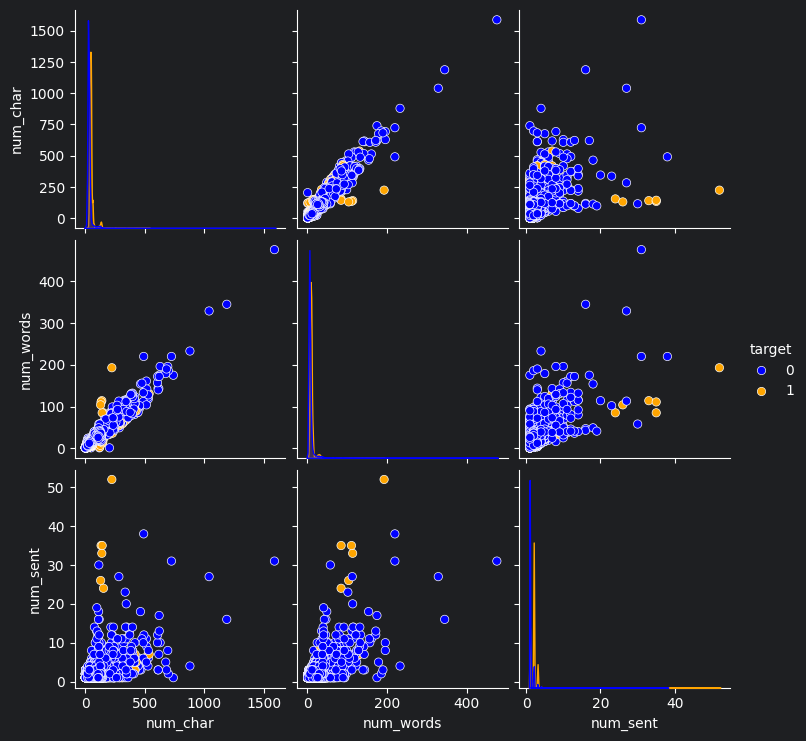

In [17]:
sns.pairplot(df,hue='target', palette={0:'blue',1:'orange'})

<Axes: >

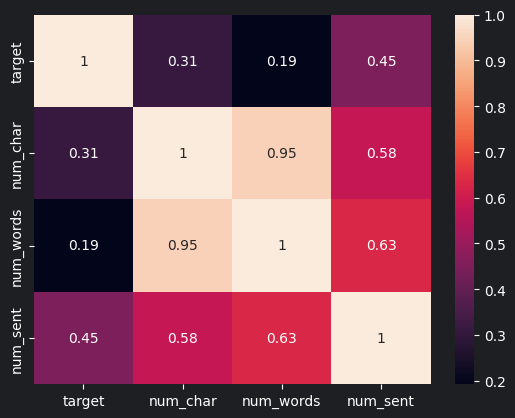

In [18]:
sns.heatmap(df.drop(['text'],axis=1).corr(),annot=True)

In [19]:
stopwords.words('english')


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [20]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [21]:
def text_pp(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(ps.stem(i))
    text=" ".join(y)
    y.clear()
    return text


In [22]:
test="MY name is Arham i am an engineering student."
print(text_pp(test))

name arham engin student


In [23]:
df['transformed_text']=df['text'].apply(text_pp)

In [24]:
df.head()

,text,target,num_char,num_words,num_sent,transformed_text
0,CONGRATULATIONS! FREE 2GB data is yours! Claim...,1,90,17,4,congratul free 2gb data claim airtel thank app...
1,Hi! Thank you for being with Vi-India's FASTES...,1,131,30,4,hi thank fastest 4g love improv click http sha...
2,"As part of Cyber Swachhta Pakhwada, CERT-In Go...",1,123,27,2,part cyber swachhta pakhwada goi advis keep di...
3,I will try to manage took tablets,0,27,7,1,tri manag took tablet
4,Study from Home with Vi!! Watch Kite Victers C...,1,115,28,4,studi home vi watch kite victer channel free m...


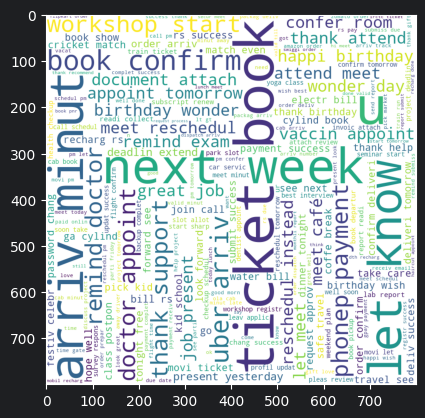

In [25]:
wc=WordCloud(width=800, height=800, background_color='white',)
spam_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

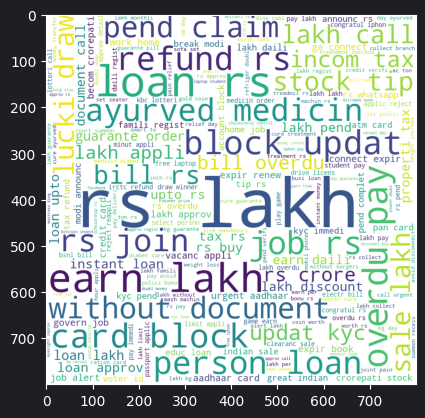

In [26]:
ham_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

In [27]:
df[df['target']==0]['transformed_text']


3                                     tri manag took tablet
5                                              get fix asap
6                                                 imag omit
7                                   sure join tomorrow morn
12                                                       hi
                                ...                        
109430    husband sir meri wife kho gai hai postman ye p...
109431    husband mai tumhari roz ki farmaishon se tang ...
109432    husband wife se bola hata lo apn chehr se ye z...
109433    husband meri zindagi kyatel kyawif kya laanat ...
109434    husband wife hata lo apn chehr se ye zulf khud...
Name: transformed_text, Length: 56973, dtype: str

In [28]:
a=df[df['target']==0]['transformed_text'].tolist()

In [29]:
spam_corpus=[]
for msg in a:
    for word in msg.split():
        spam_corpus.append(word)
print(spam_corpus)

['tri', 'manag', 'took', 'tablet', 'get', 'fix', 'asap', 'imag', 'omit', 'sure', 'join', 'tomorrow', 'morn', 'hi', 'start', 'discuss', 'topic', 'happi', '2021', 'one', 'may', 'obstruct', 'constraint', 'remov', 'may', 'clariti', 'peac', 'mind', 'healthi', 'bodi', 'new', 'year', 'work', 'infront', 'ac', 'fortun', 'buy', 'paytm', 'week', 'turn', 'profit', 'msg', 'sent', 'mistak', 'learn', 'make', 'peopl', 'grow', 'continu', 'enough', 'knowledg', 'gain', 'firm', 'foothold', 'market', 'matter', 'field', 'need', 'keep', 'learn', 'knowledg', 'capit', 'accumul', 'wealth', 'ye', 'trend', 'consist', 'upward', 'make', 'profit', 'share', 'tonight', 'tomorrow', 'night', 'bought', '200', 'share', 'good', 'even', 'index', 'adjust', 'usual', 'follow', 'gradual', 'inclus', 'process', 'inflow', 'fund', 'also', 'carri', 'stage', 'hi', 'team', 'hi', 'team', 'haha', 'anyway', 'professor', 'compens', 'afraid', 'make', 'profit', 'best', 'outcom', 'least', 'wo', 'make', 'professor', 'spend', 'earn', 'market',

In [30]:
t=pd.DataFrame(Counter(spam_corpus).most_common(50))

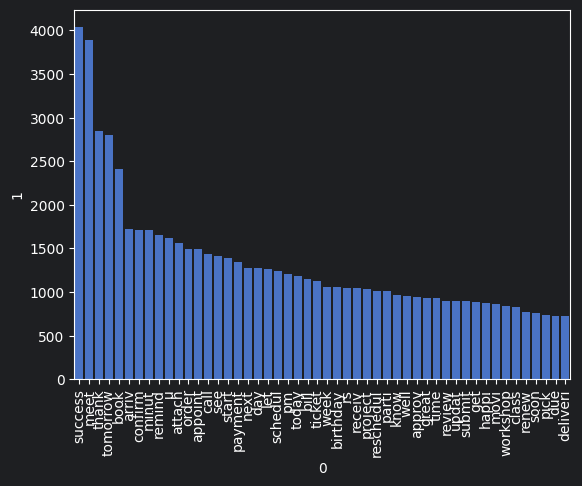

In [31]:
sns.barplot(x=t[0],y=t[1])
plt.xticks(rotation=90)
plt.show()

In [32]:
b=df[df['target']==1]['transformed_text'].tolist()

In [33]:
ham_corpus=[]
for msg in b:
    for word in msg.split():
        ham_corpus.append(word)


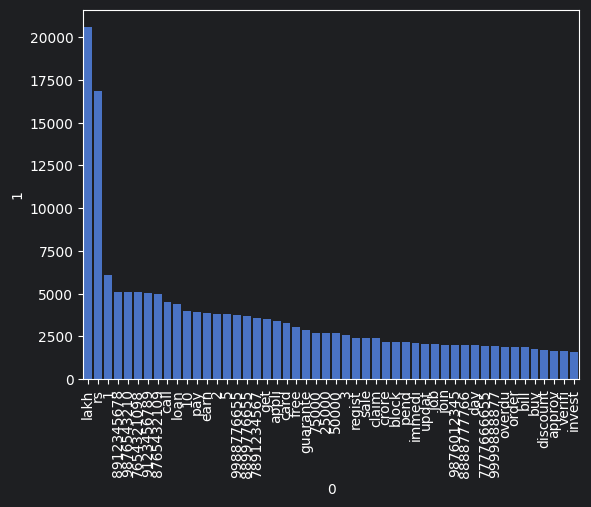

In [34]:
u=pd.DataFrame(Counter(ham_corpus).most_common(50))
sns.barplot(x=u[0],y=u[1])
plt.xticks(rotation=90)
plt.show()

TEXT VECTORIZATION


In [35]:
tfidf=TfidfVectorizer(max_features=8000)
cv=CountVectorizer()

In [36]:
X=tfidf.fit_transform(df['transformed_text'])
X1=cv.fit_transform(df['transformed_text'])
print(X.shape)
print(X1.shape)

(109435, 8000)
(109435, 13258)


In [37]:
y,y1=df['target'],df['target']


In [38]:
X_train,X_test,y_train,y_test=tts(X,y,test_size=0.2,random_state=10)

In [39]:
X1_train,X1_test,y1_train,y1_test=tts(X1,y1,test_size=0.2,random_state=10)

In [40]:
#import models
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import ExtraTreeClassifier

gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()
sgdc=SGDClassifier(random_state=2,max_iter=5000)
abc=AdaBoostClassifier(n_estimators=50 ,random_state=10)
svc=LinearSVC()
rf=RandomForestClassifier(max_depth=20,random_state=10)
etc=ExtraTreeClassifier(random_state=10)



In [41]:
clfs={
    'mnb':mnb,
    'bnb':bnb,
    'sgdc':sgdc,
    'rf':rf,
    'etc':etc,
    'abc':abc,
    'svc':svc,
}

def train(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    acc,prec=accuracy_score(y_test,y_pred),precision_score(y_test,y_pred)
    return acc,prec

accuracy_tfidf=[]
accuracy_cv=[]
precision_tfidf=[]
precision_cv=[]

for clf in clfs.values():
    acc,pred=train(clf,X_train,y_train,X_test,y_test)
    accuracy_tfidf.append(acc)
    precision_tfidf.append(pred)
    acc,pred=train(clf,X1_train,y1_train,X1_test,y1_test)
    accuracy_cv.append(acc)
    precision_cv.append(pred)

stats=pd.DataFrame({'Model':clfs.keys(),'Accuracy_TFIDF':accuracy_tfidf,'Precision_TFIDF':precision_tfidf,'Accuracy_CV':accuracy_cv, 'Precision_CV':precision_cv})


In [42]:
stats

,Model,Accuracy_TFIDF,Precision_TFIDF,Accuracy_CV,Precision_CV
0,mnb,0.984100,0.980881,0.982181,0.975986
1,bnb,0.990862,0.990439,0.990862,0.990345
2,sgdc,0.992507,0.999031,0.996619,0.998560
3,rf,0.975967,0.999799,0.972861,0.997780
4,etc,0.990588,0.990903,0.991182,0.992044
5,abc,0.823731,0.972107,0.825467,0.972258
6,svc,0.996573,0.998560,0.996619,0.998368


In [47]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc1=SVC(kernel='rbf')
param={
    'C':[0.1,1,10,100],
    'gamma':['scale','auto',0.1,0.01,0.001],
}


In [48]:
model=GridSearchCV(svc1,param_grid=param,cv=3, verbose=10, n_jobs=-1)
model.fit(X_train,y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [49]:
para=model.best_params_
para

{'C': 10, 'gamma': 0.1}

In [50]:
y_pred=model.predict(X_test)
print("\n-----Classification Report-----")

rbf_svc={'Accuracy':accuracy_score(y_test,y_pred),'Precision':precision_score(y_test,y_pred)}
print(rbf_svc)



-----Classification Report-----
{'Accuracy': 0.9970302005756841, 'Precision': 0.9983697736862294}


In [51]:
param_grid={
    'max_iter':[2000,3000,5000,7000],
    'loss': ['modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'l1_ratio': [0.15, 0.5, 0.85]
}
model1=GridSearchCV(sgdc,param_grid, cv=5,n_jobs=-1,verbose=10, scoring=['precision','accuracy'],refit='accuracy')
model1.fit(X1_train,y1_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SGDClassifier...andom_state=2)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...], 'l1_ratio': [0.15, 0.5, ...], 'loss': ['modified_huber'], 'max_iter': [2000, 3000, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['precision', 'accuracy']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

In [52]:
y_pred1=model1.predict(X1_test)
print(model1.best_params_)
acc_sgdc,prec_sgdc=[],[]
acc_sgdc.append(accuracy_score(y_test,y_pred1))
prec_sgdc.append(precision_score(y_test,y_pred1))

{'alpha': 0.001, 'l1_ratio': 0.15, 'loss': 'modified_huber', 'max_iter': 2000, 'penalty': 'l2'}


In [53]:
param_grid={
    'max_iter':[2000,3000,5000,7000],
    'loss': ['modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.00001,0.0001, 0.001],
    'l1_ratio': [0.01,0.05,0.1,0.15]
}
model2=GridSearchCV(sgdc,param_grid, cv=5,n_jobs=-1,verbose=10, scoring=['precision','accuracy'],refit='accuracy')
model2.fit(X_train,y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SGDClassifier...andom_state=2)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1e-05, 0.0001, ...], 'l1_ratio': [0.01, 0.05, ...], 'loss': ['modified_huber'], 'max_iter': [2000, 3000, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['precision', 'accuracy']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [54]:
model2.best_params_

{'alpha': 1e-05,
 'l1_ratio': 0.01,
 'loss': 'modified_huber',
 'max_iter': 2000,
 'penalty': 'elasticnet'}

In [55]:
para_sgdc=[]

In [56]:
para_sgdc.append(param_grid)

In [57]:
print(para_sgdc)

[{'max_iter': [2000, 3000, 5000, 7000], 'loss': ['modified_huber'], 'penalty': ['l2', 'l1', 'elasticnet'], 'alpha': [1e-05, 0.0001, 0.001], 'l1_ratio': [0.01, 0.05, 0.1, 0.15]}]


In [58]:
scores=[]

In [59]:
predic=model2.predict(X_test)
scores.append({'Accuracy':accuracy_score(predic,y_test),'Precision':precision_score(predic,y_test)})
print(scores)

[{'Accuracy': 0.9965733083565587, 'Precision': 0.9944545367625968}]


In [60]:
y_pred2=model2.predict(X_test)
print(model2.best_params_)
acc_sgdc.append(accuracy_score(y_test,y_pred2))
prec_sgdc.append(precision_score(y_test,y_pred2))

{'alpha': 1e-05, 'l1_ratio': 0.01, 'loss': 'modified_huber', 'max_iter': 2000, 'penalty': 'elasticnet'}


In [61]:
final_models=pd.DataFrame({'Model':['LinearSVC','SVC','SGDC_TFIDF','SGDC_CV'],'Accuracy':[accuracy_tfidf[6],accuracy_score(y_test,y_pred),acc_sgdc[0],acc_sgdc[1]],'Precision':[precision_tfidf[6],precision_score(y_test,y_pred),prec_sgdc[0],prec_sgdc[1]]})

In [62]:
final_models

,Model,Accuracy,Precision
0,LinearSVC,0.996573,0.998560
1,SVC,0.997030,0.998370
2,SGDC_TFIDF,0.995248,0.998652
3,SGDC_CV,0.996573,0.998368


In [63]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
sc=StackingClassifier(
    estimators=[('LinearSVC',make_pipeline(tfidf,svc)),('SVC',make_pipeline(tfidf,SVC(kernel='rbf',C=10,gamma=0.1,probability=True))),('SGDC_TFIDF',make_pipeline(tfidf,SGDClassifier(alpha=0.001,l1_ratio=0.15,loss='modified_huber',penalty='l2',max_iter=5000,random_state=10))),('SGDC_CV',make_pipeline(cv,SGDClassifier(alpha=0.0001,l1_ratio=0.15,loss='modified_huber',penalty='l2',max_iter=5000,random_state=10)))],
    final_estimator=LogisticRegression(),
    cv=5,
    verbose=10,
    n_jobs=-1,
)

In [64]:
X_raw=df['transformed_text']
X_raw_train,X_raw_test,y_raw_train,y_raw_test=tts(X_raw,y,test_size=0.2, random_state=10)

In [65]:
sc.fit(X_raw_train,y_raw_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('LinearSVC', ...), ('SVC', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",10
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meani

In [89]:
y_sc_pred=sc.predict(X_raw_test)

In [91]:
print("\n-----Classification Report-----")
print(accuracy_score(y_raw_test,y_sc_pred))
print(precision_score(y_raw_test,y_sc_pred))


-----Classification Report-----
0.9971215790195093
0.9978927203065134


In [84]:
sc_with_rf=StackingClassifier(
    estimators=[('LinearSVC',make_pipeline(tfidf,svc)),('SVC',make_pipeline(tfidf,SVC(kernel='rbf',C=10,gamma=0.1,probability=True))),('SGDC_TFIDF',make_pipeline(tfidf,SGDClassifier(alpha=0.001,l1_ratio=0.15,loss='modified_huber',penalty='l2',max_iter=5000,random_state=10))),('SGDC_CV',make_pipeline(cv,SGDClassifier(alpha=0.0001,l1_ratio=0.15,loss='modified_huber',penalty='l2',max_iter=5000,random_state=10))),('RandomForest',make_pipeline(tfidf,RandomForestClassifier(max_depth=40,n_estimators=75)))],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1,
)
sc_with_rf.fit(X_raw_train,y_raw_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('LinearSVC', ...), ('SVC', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meanin

In [92]:
y_rf=sc_with_rf.predict(X_raw_test)
print("\n-----Classification Report-----")
print(accuracy_score(y_raw_test,y_rf))
print(precision_score(y_raw_test,y_rf))


-----Classification Report-----
0.9971215790195093
0.9978927203065134


In [93]:
rf2=RandomForestClassifier(n_jobs=-1,random_state=10)
param_grid={
    'n_estimators':[50,100,150,200],
    'max_depth':[20,25,30,35,40],
    'max_samples':[0.2,0.3,0.4,None]
}
rf_gcv=GridSearchCV(rf2,param_grid,cv=3, verbose=10, n_jobs=-1, scoring=['precision','accuracy'],refit='accuracy')
rf_gcv.fit(X_train,y_train)

Fitting 3 folds for each of 80 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [20, 25, ...], 'max_samples': [0.2, 0.3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['precision', 'accuracy']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [80]:
params=[]

In [94]:

params.append(rf_gcv.best_params_)
print(params)

[{'max_depth': 40, 'max_samples': None, 'n_estimators': 150}, {'max_depth': 40, 'max_samples': None, 'n_estimators': 150}]


In [82]:
y_rf_gcv=[]


In [95]:
e=rf_gcv.predict(X_test)
y_rf_gcv.append({'Accuracy':accuracy_score(y_test,e),'Precision':precision_score(y_test,e)})

In [96]:
print(y_rf_gcv)

[{'Accuracy': 0.9858820304290218, 'Precision': 0.9999014972419228}, {'Accuracy': 0.9858820304290218, 'Precision': 0.9999014972419228}]


In [97]:
best_random_forest={'param':params[1],'model':rf2,'stats':y_rf_gcv[0]}

In [98]:
best_rbf_SVC={'param':para,'model':svc1,'stats':rbf_svc}

In [99]:
svc2=LinearSVC(dual=False,random_state=10)
params_svc2=[]
y_pred_svc2=[]

In [100]:
temp_params=[{
    'max_iter':[1000,2000,3000],
    'C':[0.01,0.1,1,10],
    'penalty':['l1','l2'],
    'loss':['squared_hinge']
    }
]
params_svc2.append(temp_params)

In [101]:
svc2_grid=GridSearchCV(svc2,temp_params,cv=3, n_jobs=-1, scoring=['precision','accuracy'],refit='accuracy', verbose=5)
svc2_grid.fit(X_train,y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(dua...ndom_state=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'loss': ['squared_hinge'], 'max_iter': [1000, 2000, ...], 'penalty': ['l1', 'l2']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['precision', 'accuracy']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold

In [102]:
y_svc2=svc2_grid.predict(X_test)

In [103]:
lin_svc={'Accuracy':(accuracy_score(y_test,y_svc2)),'Precision':precision_score(y_test,y_svc2)}
print(lin_svc)

{'Accuracy': 0.9965733083565587, 'Precision': 0.998559631265604}


In [105]:
best_linear_svc={'param':params_svc2[0],'model':svc2,'stats':lin_svc}

In [106]:
best_sgdc={'param':para_sgdc[0],'model':sgdc,'stats':{'Accuracy':acc_sgdc[1],'Precision':prec_sgdc[1]}}

In [107]:
best_stacking={'param':None,'model':sc_with_rf,'stats':{'Accuracy':accuracy_score(y_raw_test,y_rf),'Precision':precision_score(y_raw_test,y_rf)}}

In [108]:
final_stats=pd.DataFrame({'Model':['Stacking Classifier','SGDClassifier','LinearSVC','SVM','RandomForest'],'Accuracy':[best_stacking['stats']['Accuracy'],best_sgdc['stats']['Accuracy'],best_linear_svc['stats']['Accuracy'],accuracy_score(y_test,y_pred),best_random_forest['stats']['Accuracy']],'Precision':[best_stacking['stats']['Precision'],best_sgdc['stats']['Precision'],best_linear_svc['stats']['Precision'],precision_score(y_test,y_pred),best_random_forest['stats']['Precision']]})

In [109]:
final_stats


,Model,Accuracy,Precision
0,Stacking Classifier,0.997122,0.997893
1,SGDClassifier,0.996573,0.998368
2,LinearSVC,0.996573,0.998560
3,SVM,0.997030,0.998370
4,RandomForest,0.985882,0.999901


In [110]:
import pickle as pkl
pkl.dump(tfidf,open('Vectorizer.pkl',"wb"))
pkl.dump(rf_gcv,open('Model.pkl',"wb"))